### Demo AUC-ROC

In [1]:
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# generate two class dataset
X, y = make_classification(n_samples=1000, n_classes=2, n_features=20, random_state=27)

# split into train-test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=27)

#print(pd.DataFrame(X))
#print(pd.Series(y))

In [2]:
# train models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# logistic regression
model1 = LogisticRegression()
# knn
model2 = KNeighborsClassifier(n_neighbors=4)

# fit model
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)

# predict probabilities
pred_prob1 = model1.predict_proba(X_test)
pred_prob2 = model2.predict_proba(X_test)

In [3]:
pred_prob2[:3,1]

array([0.5 , 0.  , 0.75])

In [4]:
from sklearn.metrics import roc_curve

# roc curve for models
fpr1, tpr1, thresh1 = roc_curve(y_test, pred_prob1[:,1], pos_label=1)
fpr2, tpr2, thresh2 = roc_curve(y_test, pred_prob2[:,1], pos_label=1)

# roc curve for tpr = fpr 
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, _ = roc_curve(y_test, random_probs, pos_label=1)

In [5]:
from sklearn.metrics import roc_auc_score

# auc scores
auc_score1 = roc_auc_score(y_test, pred_prob1[:,1])
auc_score2 = roc_auc_score(y_test, pred_prob2[:,1])

print(auc_score1, auc_score2)

0.9762374461979914 0.9233769727403157


In [6]:
# # matplotlib
# import matplotlib.pyplot as plt
# plt.style.use('seaborn')

# # plot roc curves
# plt.plot(fpr1, tpr1, linestyle='--',color='orange', label='Logistic Regression')
# plt.plot(fpr2, tpr2, linestyle='--',color='green', label='KNN')
# plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
# # title
# plt.title('ROC curve')
# # x label
# plt.xlabel('False Positive Rate')
# # y label
# plt.ylabel('True Positive rate')

# plt.legend(loc='best')
# # plt.savefig('ROC',dpi=300)
# plt.show();

# AUC-ROC

In [7]:
import warnings,os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from keras.models import load_model

from tensorflow.keras.preprocessing.image import ImageDataGenerator
warnings.filterwarnings("ignore")

2025-04-09 09:39:26.862350: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-09 09:39:30.538382: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-09 09:39:30.544582: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-09 09:39:42.475346: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [11]:
# seed used in training
seed = 42

# Set the image size and batch size
image_size = (224, 224)  # Inception V3 input size
batch_size = 32

dataset_dir = '/data'

In [12]:
# Prepare data using ImageDataGenerator with validation split
datagen = ImageDataGenerator(rescale=1.0/255.0, validation_split=0.2)

# Create the validation generator
val_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    seed = seed,
    shuffle=False
)

Found 3006 images belonging to 2 classes.


## Extracting True Labels

In [13]:
y_val_true = np.array(val_generator.classes)

## AUC-ROC Plotting Function

In [14]:
def plot_roc_auc(y_val_true, y_val_prob):
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_val_true, y_val_prob)
    
    # Calculate AUC
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.figure()
    lw = 2
    plt.plot(fpr, tpr, color='darkorange',
             lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)

    
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic Curve')
    plt.legend(loc="lower right")
    plt.show()

# def plot_roc_auc_models(y_val_true, models_prob, model_names,image_name='AUC-ROC-COMPARISON.png'):
#     plt.figure(facecolor='w')
#     lw = 2
#     colors = ['darkorange', 'blue', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    
#     for i, model_prob in enumerate(models_prob):
#         # Calculate ROC curve
#         fpr, tpr, _ = roc_curve(y_val_true, model_prob)
        
#         # Calculate AUC
#         roc_auc = auc(fpr, tpr)
        
#         # Plot ROC curve
#         plt.plot(fpr, tpr, color=colors[i % len(colors)],linestyle='--',
#                  lw=lw, label=f'{model_names[i]} ROC curve (area = {roc_auc:.2f})')
    
#     plt.plot([0, 1], [0, 1], color='navy', lw=lw#, linestyle='--'
#             )
#     plt.xlim([0.0, 1.0])
#     plt.ylim([0.0, 1.05])
#     plt.xlabel('False Positive Rate')
#     plt.ylabel('True Positive Rate')
#     plt.title('Receiver Operating Characteristic Curve')
#     plt.legend(loc="lower right")
#     plt.savefig(image_name,dpi=300)
#     plt.show()
def plot_roc_auc_models(y_val_true, models_prob, model_names, image_name='AUC-ROC-COMPARISON.png'):
    plt.figure(facecolor='w')
    ax = plt.gca()  # Get current axes
    ax.set_facecolor('white')  # Set axes facecolor to white

    lw = 2
    colors = ['darkorange', 'blue', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    
    for i, model_prob in enumerate(models_prob):
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_val_true, model_prob)
        
        # Calculate AUC
        roc_auc = auc(fpr, tpr)
        
        # Plot ROC curve
        plt.plot(fpr, tpr, color=colors[i % len(colors)], linestyle='--',
                 lw=lw, label=f'{model_names[i]} ROC curve (area = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], color='navy', lw=lw)  # Plot diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic Curve')
    plt.legend(loc="lower right")
    plt.savefig(image_name, dpi=300, facecolor='w', bbox_inches='tight')  # Save with white background
    plt.show()


## MODELS

In [16]:
alexnet_model_path   = '/app/model-weights/RGB-Based-CNN/alexnet_results/alexnet_best_weights.tf' # Load your trained CNN model
resnet_model_path    = '/app/model-weights/RGB-Based-CNN/resnet_results/resnet_best_weights.tf' # Load your trained CNN model
inception_model_path = '/app/model-weights/RGB-Based-CNN/inceptionv3_results/inception_best_weights.tf'
vgg_model_path       = '/app/model-weights/RGB-Based-CNN/vgg16_results/vgg_best_weights.tf'

alexnet_model = load_model(alexnet_model_path)
resnet_model = load_model(resnet_model_path)
inception_model = load_model(inception_model_path)
vgg_model = load_model(vgg_model_path)

In [7]:
#alexnet_model.summary()

In [17]:
# Extract configuration of the model
# model_config = alexnet_model.get_config()
# #print(model_config)
# # Extract configuration of layers
# #for layer in alexnet_model.layers:
#     #print(layer.get_config())
# alexnet_model.optimizer.get_config()

In [18]:
val_loss, val_acc = alexnet_model.evaluate(val_generator)
print('alexnet_model\n\tval_loss :',val_loss,"\n\tval_acc :", val_acc,'\n')

val_loss, val_acc = resnet_model.evaluate(val_generator)
print('resnet_model\n\tval_loss :',val_loss,"\n\tval_acc :", val_acc,'\n')

val_loss, val_acc = inception_model.evaluate(val_generator)
print('inception_model\n\tval_loss :',val_loss,"\n\tval_acc :", val_acc,'\n')

val_loss, val_acc = vgg_model.evaluate(val_generator)
print('vgg_model\n\tval_loss :',val_loss,"\n\tval_acc :", val_acc,'\n')

94/94 [==============================] - 163s 2s/step - loss: 0.1300 - accuracy: 0.9737
alexnet_model
	val_loss : 0.13003301620483398 
	val_acc : 0.9737192392349243 

94/94 [==============================] - 79s 829ms/step - loss: 0.2162 - accuracy: 0.9358
resnet_model
	val_loss : 0.2161705046892166 
	val_acc : 0.9357950687408447 

94/94 [==============================] - 53s 545ms/step - loss: 0.0664 - accuracy: 0.9777
inception_model
	val_loss : 0.06642348319292068 
	val_acc : 0.9777112603187561 

94/94 [==============================] - 96s 1s/step - loss: 0.0364 - accuracy: 0.9880
vgg_model
	val_loss : 0.03641051799058914 
	val_acc : 0.9880239367485046 



In [19]:
# Make predictions
alexnet_y_val_prob = alexnet_model.predict(val_generator)
resne_y_val_prob = resnet_model.predict(val_generator)
inception_y_val_prob = inception_model.predict(val_generator)
vgg_y_val_prob = vgg_model.predict(val_generator)

94/94 [==============================] - 95s 1s/step


In [20]:
models_prob = [alexnet_y_val_prob,inception_y_val_prob,resne_y_val_prob,vgg_y_val_prob]
model_names = ['AlexNet','InceptionV3','ResNet50','VGG16']

In [21]:
# Plot ROC curve using predicted probabilities
# plot_roc_auc(y_val_true, alexnet_y_val_prob)

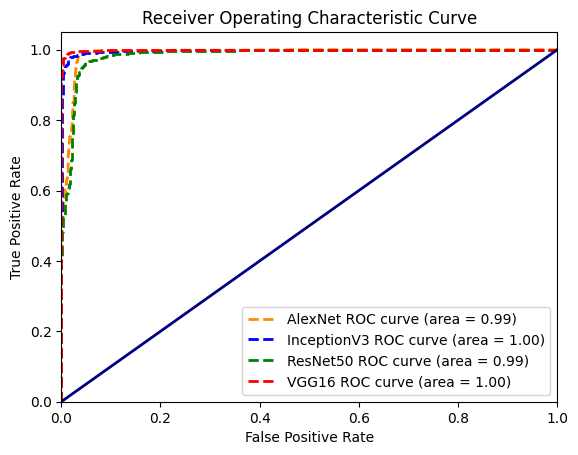

In [22]:
plot_roc_auc_models(y_val_true, models_prob, model_names)

In [45]:
model_prob_dict = {
    'AlexNet':alexnet_y_val_prob,
    'InceptionV3':inception_y_val_prob,
    'ResNet50':resne_y_val_prob,
    'VGG16':vgg_y_val_prob
}

In [46]:
from sklearn.metrics import roc_auc_score,accuracy_score

# Assuming y_true contains true labels (0s and 1s) and y_pred contains predicted probabilities
# y_true and y_pred should be numpy arrays or lists
for model,model_prob in model_prob_dict.items():
    # Calculate AUC score
    auc_score = roc_auc_score(list(y_val_true), model_prob)
    y_pred = (model_prob > 0.5).astype(int).flatten()
    acc = accuracy_score(y_val_true, y_pred)
    print(f"{model}\n\tAUC Score:", auc_score,'\n\tAccuracy:',acc)


AlexNet
	AUC Score: 0.990039658983209 
	Accuracy: 0.9737192282102461
InceptionV3
	AUC Score: 0.9969406939060447 
	Accuracy: 0.97771124417831
ResNet50
	AUC Score: 0.9852607935603621 
	Accuracy: 0.9357950765136394
VGG16
	AUC Score: 0.9991536111631251 
	Accuracy: 0.9880239520958084


In [47]:
from sklearn.metrics import cohen_kappa_score,\
                            precision_score,\
                            recall_score,\
                            f1_score

models_metrics_map = dict()

for model,model_prob in model_prob_dict.items():
    y_pred = (model_prob > 0.5).astype(int).flatten()
    
    precision = precision_score(y_val_true, y_pred
                               # ,average=None
                               )
    recall = recall_score(y_val_true, y_pred
                         # ,average=None
                         )
    f1 = f1_score(y_val_true, y_pred
                 # ,average=None
                 )
    kappa = cohen_kappa_score(y_val_true, y_pred)
    
    # Calculate AUC score
    auc_score = roc_auc_score(list(y_val_true), model_prob)
    
    print(model)
    # Interpretation based on the kappa value
    if kappa < 0:
        interpretation = "Less than chance agreement"
    elif 0 <= kappa <= 0.20:
        interpretation = "Slight agreement"
    elif 0.21 <= kappa <= 0.40:
        interpretation = "Fair agreement"
    elif 0.41 <= kappa <= 0.60:
        interpretation = "Moderate agreement"
    elif 0.61 <= kappa <= 0.80:
        interpretation = "Substantial agreement"
    else:
        interpretation = "Almost perfect agreement"
    """
    print(f"\tprecision:", precision)
    print(f"\trecall: {recall}")
    print(f"\tf1: {f1}")
    """
    print(f"\tcohen_kappa_score: {kappa}")
    print(f"\tInterpretation: {interpretation}")
    ###-----------------------------------------Storing-Calculated-Metrics-Model-Wise---------------------------------------------#
    
    temp = dict()
    temp['y_pred_prob'] = model_prob
    temp['y_pred_label'] = y_pred

    temp['precision'] = precision
    temp['recall'] = recall
    temp['f1'] = f1
    temp['accuracy_score'] = acc
    temp['cohen_kappa_score'] = kappa
    temp['interpretation'] = interpretation
    temp['roc_auc_score'] = auc_score
    # temp['val_loss']=val_loss


    models_metrics_map[model] = temp

    ###--------------------------------------Printing--Performance-----------------------------------------------------------------#
    print(model)
    print('\taccuracy_score :',acc)
    print('\tcohen_kappa_score :',kappa)
    print('\tinterpretation :',interpretation)
    print('\troc_auc_score :',auc_score)
    print("\tprecision :", precision)
    print("\trecall :",recall)
    print("\tf1 :",f1)
    
    print()

AlexNet
	cohen_kappa_score: 0.9474384564204923
	Interpretation: Almost perfect agreement
AlexNet
	accuracy_score : 0.9880239520958084
	cohen_kappa_score : 0.9474384564204923
	interpretation : Almost perfect agreement
	roc_auc_score : 0.990039658983209
	precision : 0.9647519582245431
	recall : 0.9833666001330672
	f1 : 0.9739703459637562

InceptionV3
	cohen_kappa_score: 0.9554224883566201
	Interpretation: Almost perfect agreement
InceptionV3
	accuracy_score : 0.9880239520958084
	cohen_kappa_score : 0.9554224883566201
	interpretation : Almost perfect agreement
	roc_auc_score : 0.9969406939060447
	precision : 0.9838274932614556
	recall : 0.9713905522288756
	f1 : 0.9775694676933379

ResNet50
	cohen_kappa_score: 0.8715901530272787
	Interpretation: Almost perfect agreement
ResNet50
	accuracy_score : 0.9880239520958084
	cohen_kappa_score : 0.8715901530272787
	interpretation : Almost perfect agreement
	roc_auc_score : 0.9852607935603621
	precision : 0.9671897289586305
	recall : 0.90219560878243

In [48]:
df = pd.DataFrame.from_dict(models_metrics_map)#, orient='columns'
# Set the index
df.index.name = 'CNN'

# Print the DataFrame
df.drop(index=['y_pred_prob','y_pred_label'],inplace=True)
df = df.transpose()
# Sort the DataFrame by column 'a' in ascending order
df_sorted_asc = df.sort_index()
df_sorted_asc

CNN,precision,recall,f1,accuracy_score,cohen_kappa_score,interpretation,roc_auc_score
AlexNet,0.964752,0.983367,0.97397,0.988024,0.947438,Almost perfect agreement,0.99004
InceptionV3,0.983827,0.971391,0.977569,0.988024,0.955422,Almost perfect agreement,0.996941
ResNet50,0.96719,0.902196,0.933563,0.988024,0.87159,Almost perfect agreement,0.985261
VGG16,0.987375,0.988689,0.988032,0.988024,0.976048,Almost perfect agreement,0.999154


In [49]:
df_sorted_asc.to_csv('RGB-Based-Evaluations.csv')

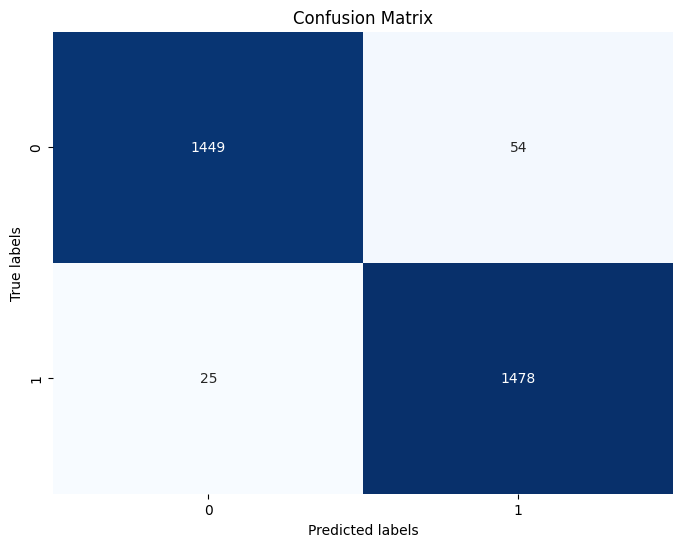

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Convert probabilities to binary predictions using a threshold of 0.5
y_pred = (alexnet_y_val_prob > 0.5).astype(int).flatten()
# Compute confusion matrix
cm = confusion_matrix(y_val_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [33]:
# pip install seaborn